17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.7067 - loss: 0.5487 - val_accuracy: 0.8118 - val_loss: 0.4295
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.8654 - loss: 0.3285 - val_accuracy: 0.8298 - val_loss: 0.3905
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9110 - loss: 0.2321 - val_accuracy: 0.8478 - val_loss: 0.3941
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9579 - loss: 0.1217 - val_accuracy: 0.7904 - val_loss: 0.5000
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.9796 - loss: 0.0662 - val_accuracy: 0.8320 - val_loss: 0.5227
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.8236 - loss: 0.5584
Test Accuracy: 0.823639988899231


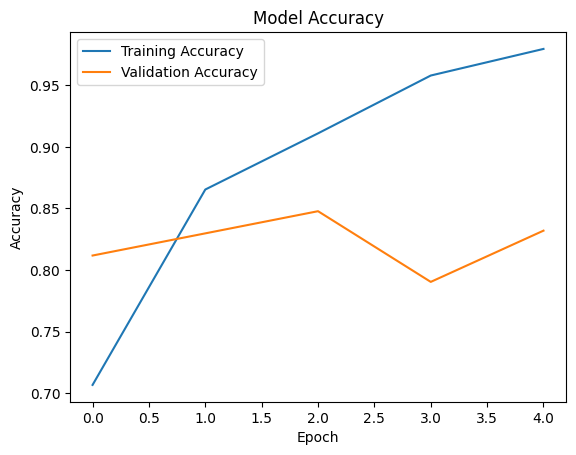

In [1]:
############
# RNN for Text classification
#
###########
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

# Load IMDB dataset (top 10,000 most frequent words)
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences so all reviews have the same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# Build the RNN model
model = Sequential()

# Embedding layer converts word indexes into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=32))

# Simple RNN layer for sequential text processing
model.add(SimpleRNN(32))

# Output layer for binary classification (positive / negative)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate model on test data
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()